# Forecasting

## Environment setup

This section contains the Python libraries, user-defined functions, and data loading required for the analysis.

In [644]:
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL, MSTL

# Modeling libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [645]:
def add_seasonal_background(ax, data):
    '''
    Function that adds different background colors for each season. 
    It will be used later for visualization purposes.
    '''

    min_date = data["datadatetime"].min()
    max_date = data["datadatetime"].max() + pd.DateOffset(months=1)

    min_year = min_date.year
    max_year = max_date.year

    for year in range(min_year, max_year + 1):

        seasons = [
            ("01-01", "03-01", "lightblue"),   # Winter
            ("03-01", "06-01", "lightgreen"),  # Spring
            ("06-01", "09-01", "khaki"),       # Summer
            ("09-01", "12-01", "moccasin"),    # Autumn
            ("12-01", "01-01", "lightblue")    # Winter
        ]

        for start, end, color in seasons:

            start_date = pd.Timestamp(f"{year}-{start}")

            if end == "01-01":
                end_date = pd.Timestamp(f"{year + 1}-{end}")
            else:
                end_date = pd.Timestamp(f"{year}-{end}")

            start_date = max(start_date, min_date)
            end_date = min(end_date, max_date)

            if start_date < end_date:
                ax.axvspan(
                    start_date,
                    end_date,
                    color=color,
                    alpha=0.10,
                    zorder=0
                )

In [646]:
def check_time_gaps(data, datetime_col="datadatetime"):
    '''
    Since the data is hourly, a missing hour is identified 
    by checking whether the time difference between consecutive observations is greater than one hour.
    '''

    dates = pd.to_datetime(data[datetime_col]).sort_values()

    time_diff = dates.diff()

    gaps = pd.DataFrame({
        "previous": dates.shift(),
        "current": dates,
        "difference": time_diff
    })

    gaps = gaps[gaps["difference"] > pd.Timedelta(hours=1)]

    return gaps

In [647]:
# Directory where I saved the data
data_dir = Path(
    "/Users/rolandsaleksandrsrudenko/Desktop/Faili/Job_application_homework/Enefit_Quantatative analyst"
)

syspower_path = data_dir / "SyspowerData.csv"
weather_path = data_dir / "country_level_historical_data.parquet"

# Load data using the appropriate file format

# Since the dataset is relatively small, it can be loaded into memory using pandas.
# For larger datasets, I would consider using Parquet for more efficient storage and processing.

syspower = pd.read_csv(syspower_path)
weather = pd.read_parquet(weather_path)

## Data quality

In this section, I examine the data and identify potential issues that could affect the modelling, including technical data-quality problems and possible business-logic inconsistencies.

In [648]:
print("SYPOWER")
display(syspower.head())
print(syspower.dtypes)
print("Syspower shape:", syspower.shape)

print("\nWEATHER")
display(weather.head())
print(weather.dtypes)
print("Weather shape:", weather.shape)

SYPOWER


,X.Hour,SPOTEE,SPOTLV,SPOTLT,CNPEE,CNPLT,CNPLV,PROEEWINDON_ENTSOE,PROLTWINDON_ENTSOE,PROLVWINDON_ENTSOE,PROLVSOL_ENTSOE,PROLTSOL_ENTSOE,PROEESOL_ENTSOE
0,2022-01-01 00:00,50.05,50.05,50.05,0.89,1.22,0.69,21.0,220.62,13.0,NaN,0.0,0.0
1,2022-01-01 01:00,41.33,41.33,41.33,0.87,1.18,0.67,26.9,247.19,12.0,NaN,0.0,0.0
2,2022-01-01 02:00,42.18,42.18,42.18,0.86,1.14,0.65,24.5,263.22,10.0,NaN,0.0,0.0
3,2022-01-01 03:00,44.37,44.37,44.37,0.84,1.11,0.63,32.0,251.44,12.0,NaN,0.0,0.0
4,2022-01-01 04:00,37.67,37.67,37.67,0.84,1.11,0.63,44.4,264.80,13.0,NaN,0.0,0.0


X.Hour                 object
SPOTEE                float64
SPOTLV                float64
SPOTLT                float64
CNPEE                 float64
CNPLT                 float64
CNPLV                 float64
PROEEWINDON_ENTSOE    float64
PROLTWINDON_ENTSOE    float64
PROLVWINDON_ENTSOE    float64
PROLVSOL_ENTSOE       float64
PROLTSOL_ENTSOE       float64
PROEESOL_ENTSOE       float64
dtype: object
Syspower shape: (36504, 13)

WEATHER


,datadatetime,marketareacode,weathervariable,weathervalue,periodtype
0,2017-01-01 00:00:00,ee,wind_speed_10m,5.250766,actual
1,2017-01-01 01:00:00,ee,wind_speed_10m,4.937666,actual
2,2017-01-01 02:00:00,ee,wind_speed_10m,4.607518,actual
3,2017-01-01 03:00:00,ee,wind_speed_10m,4.319775,actual
4,2017-01-01 04:00:00,ee,wind_speed_10m,4.104292,actual


datadatetime       datetime64[ns]
marketareacode             object
weathervariable            object
weathervalue              float64
periodtype                 object
dtype: object
Weather shape: (1467720, 5)


In [649]:
syspower["datadatetime"] = pd.to_datetime(syspower["X.Hour"])

syspower = syspower.drop(columns=["X.Hour"])

print(syspower["datadatetime"].min())
print(syspower["datadatetime"].max())
print("Number of rows:", len(syspower))
print("Unique timestamps:", syspower["datadatetime"].nunique())

2022-01-01 00:00:00
2026-03-01 23:00:00
Number of rows: 36504
Unique timestamps: 36504


While the Syspower dataset contains hourly data with separate columns for each country, the weather data is stored in a combined format. Data manipulation will therefore be required before the datasets can be merged for modelling. Additionally, the timestamp formats differ between the datasets, so the Syspower timestamps will need to be converted to a compatible datetime format.

In [650]:
time_diff = syspower["datadatetime"].sort_values().diff()

print(time_diff.value_counts().head(10))

0 days 01:00:00    36503
Name: datadatetime, dtype: int64


In [651]:
print("Weather date range:")
print(weather["datadatetime"].min())
print(weather["datadatetime"].max())

print("\nCountries:")
print(weather["marketareacode"].value_counts())

print("\nWeather variables:")
print(weather["weathervariable"].value_counts())

print("\nPeriod types:")
print(weather["periodtype"].value_counts())

Weather date range:
2015-01-01 00:00:00
2026-02-28 23:00:00

Countries:
ee    489240
lt    489240
lv    489240
Name: marketareacode, dtype: int64

Weather variables:
wind_speed_10m     293544
wind_speed_100m    293544
t2m                293544
solar_w_m          293544
tp                 293544
Name: weathervariable, dtype: int64

Period types:
actual    1467720
Name: periodtype, dtype: int64


Weather data is available from 2015 thats why there are 
$$
100 - \frac{36\,504}{293\,544 / 3} \times 100
= 62.7\%
$$ 

more data for each country than in syspower dataset. Each variable accroos each country is consistant, which is good. 

In [652]:
print("Syspower missing values:")
display(
    syspower.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("\nWeather missing values:")
display(
    weather.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

Syspower missing values:


,missing
PROLVSOL_ENTSOE,17521
CNPLV,32
PROEEWINDON_ENTSOE,32
CNPEE,31
CNPLT,6
SPOTLV,4
SPOTLT,4
SPOTEE,4
PROLTWINDON_ENTSOE,4
PROLVWINDON_ENTSOE,4



Weather missing values:


,missing
datadatetime,0
marketareacode,0
weathervariable,0
weathervalue,0
periodtype,0


The weather data contains no missing values. In the Syspower data, missing values are generally below 0.1% of observations, although they will still be investigated. There are larger gaps in Latvia's solar generation data, but this variable is not directly relevant to electricity demand and will not be used in the model.

It is also important to note that a missing-value check does not identify missing hourly observations, so the time series will be checked separately for hourly gaps.

In [653]:
syspower_gaps = check_time_gaps(syspower, 'datadatetime')
weather_gaps = check_time_gaps(weather)

print("Syspower time gaps:")
display(syspower_gaps)

print("\nWeather time gaps:")
display(weather_gaps)

Syspower time gaps:


,previous,current,difference



Weather time gaps:


,previous,current,difference


There are no gaps in neither of data tables

In [654]:
print(
    "Duplicate Syspower timestamps:",
    syspower["datadatetime"].duplicated().sum()
)

print(
    "Duplicate weather observations:",
    weather.duplicated(
        subset=[
            "datadatetime",
            "marketareacode",
            "weathervariable"
        ]
    ).sum()
)

Duplicate Syspower timestamps: 0
Duplicate weather observations: 0


There are no duplicate values as well

The target for modeling will be one of the energy demand columns. The accuraccy of these variables are important, so lets investigate why there are some missing values. My main goal is to look for some patterns or maybe to see whenever there was some technical issues with fetching the data

In [655]:
# Where is NA values located for demand. Are there any pattern?
# there any other technical reason for missing values
demand_cols = ["CNPEE", "CNPLV", "CNPLT"]

for col in demand_cols:
    print(f"\n{col}")
    print(
        syspower.loc[
            syspower[col].isna(),
            ["datadatetime", col]
        ]
    )


CNPEE
             datadatetime  CNPEE
2042  2022-03-27 02:00:00    NaN
10525 2023-03-15 13:00:00    NaN
10526 2023-03-15 14:00:00    NaN
10778 2023-03-26 02:00:00    NaN
14536 2023-08-29 16:00:00    NaN
14537 2023-08-29 17:00:00    NaN
14538 2023-08-29 18:00:00    NaN
14702 2023-09-05 14:00:00    NaN
14703 2023-09-05 15:00:00    NaN
15398 2023-10-04 14:00:00    NaN
15399 2023-10-04 15:00:00    NaN
15710 2023-10-17 14:00:00    NaN
15711 2023-10-17 15:00:00    NaN
17198 2023-12-18 14:00:00    NaN
17291 2023-12-22 11:00:00    NaN
17326 2023-12-23 22:00:00    NaN
19430 2024-03-20 14:00:00    NaN
19431 2024-03-20 15:00:00    NaN
19682 2024-03-31 02:00:00    NaN
20084 2024-04-16 20:00:00    NaN
20085 2024-04-16 21:00:00    NaN
20086 2024-04-16 22:00:00    NaN
21394 2024-06-10 10:00:00    NaN
28418 2025-03-30 02:00:00    NaN
33182 2025-10-14 14:00:00    NaN
33394 2025-10-23 10:00:00    NaN
33566 2025-10-30 14:00:00    NaN
33567 2025-10-30 15:00:00    NaN
33568 2025-10-30 16:00:00    NaN
336

Two types of missing observations were identified. At the end of March, the 02:00 observation is missing for each country due to the transition from winter to summer time. These observations will be excluded.

Other missing observations appear to be caused by technical issues or unusually low demand. For the remaining missing demand values, I will use the average demand for the same weekday and hour over the previous three weeks. Since the number of missing values is very small, this approach should have a negligible impact on the model.

## Preparation of data for modeling

In this section, the data quality issues identified in the previous section are addressed and the datasets are prepared for modeling.

In [656]:
# Since there is mismatch between the two data set in time zones, 
# the time is changed in order to match after the merging two data sets

weather["datadatetime"] = weather["datadatetime"] + pd.Timedelta(hours=1)

In [657]:
# These date are taken out from development data set because at those dates time changed from 02 to 03 
# across all baltic countries and is not relevent to modeling

dst_dates = [
    "2022-03-27 02:00:00",
    "2023-03-26 02:00:00",
    "2024-03-31 02:00:00",
    "2025-03-30 02:00:00"
]

model_df = syspower.copy()

model_df = model_df[
    ~model_df["datadatetime"].isin(pd.to_datetime(dst_dates))
].copy()

In [658]:
# Creating very simple imputation. Taking previous values at the same day and hour for the past three months and calculating the avarage
# Since missing values are very small porportion of data set, then even if the method is wrong, it will not cause significant model biase.

demand_cols = ["CNPEE", "CNPLV", "CNPLT"]

for demand_col in demand_cols:
    for weeks in [1, 2, 3]:
        model_df[f"{demand_col}_lag_{weeks}w"] = (
            model_df[demand_col].shift(168 * weeks)
        )

    lag_cols = [
        f"{demand_col}_lag_{w}w"
        for w in [1, 2, 3]
    ]

    model_df[f"{demand_col}_imputation"] = model_df[lag_cols].mean(axis=1)

    model_df[demand_col] = model_df[demand_col].fillna(
        model_df[f"{demand_col}_imputation"]
    )

    model_df = model_df.drop(
        columns=lag_cols + [f"{demand_col}_imputation"]
    )

In [659]:
# There are no missing values after the imputation
demand_cols = ["CNPEE", "CNPLV", "CNPLT"]

for col in demand_cols:
    print(f"\n{col}")
    print(
        model_df.loc[
            model_df[col].isna(),
            ["datadatetime", col]
        ]
    )


CNPEE
Empty DataFrame
Columns: [datadatetime, CNPEE]
Index: []

CNPLV
Empty DataFrame
Columns: [datadatetime, CNPLV]
Index: []

CNPLT
Empty DataFrame
Columns: [datadatetime, CNPLT]
Index: []


In [660]:
# I have decited to select Latvia as modelling country, thus weather data is selected only from Latvia
# Additionally I transformed data set where each wheather variables is in its own column

weather_lv = weather[
    weather["marketareacode"] == "lv"
].copy()

weather_wide_lv = (
    weather_lv
    .pivot_table(
        index="datadatetime",
        columns="weathervariable",
        values="weathervalue"
    )
    .reset_index()
)

weather_wide_lv.head()

weathervariable,datadatetime,solar_w_m,t2m,tp,wind_speed_100m,wind_speed_10m
0,2015-01-01 01:00:00,0.0,1.979153,0.000001,7.813304,4.241307
1,2015-01-01 02:00:00,0.0,1.989453,0.000001,7.795859,4.232970
2,2015-01-01 03:00:00,0.0,2.112345,0.000001,7.882537,4.288570
3,2015-01-01 04:00:00,0.0,2.150615,0.000002,7.957607,4.355542
4,2015-01-01 05:00:00,0.0,2.166764,0.000005,7.917286,4.336493


## Exploratory data analysis (EDA)

In this section, I explore how the variables behave over time and identify potential variables to include in the model.

In [661]:
country_names = {
    "CNPEE": "Estonia",
    "CNPLV": "Latvia",
    "CNPLT": "Lithuania"
}
country_colors = {
    "CNPEE": "#0072B2",   # Estonia
    "CNPLV": "#C8102E",   # Latvia
    "CNPLT": "#F2C500"    # Lithuania
}

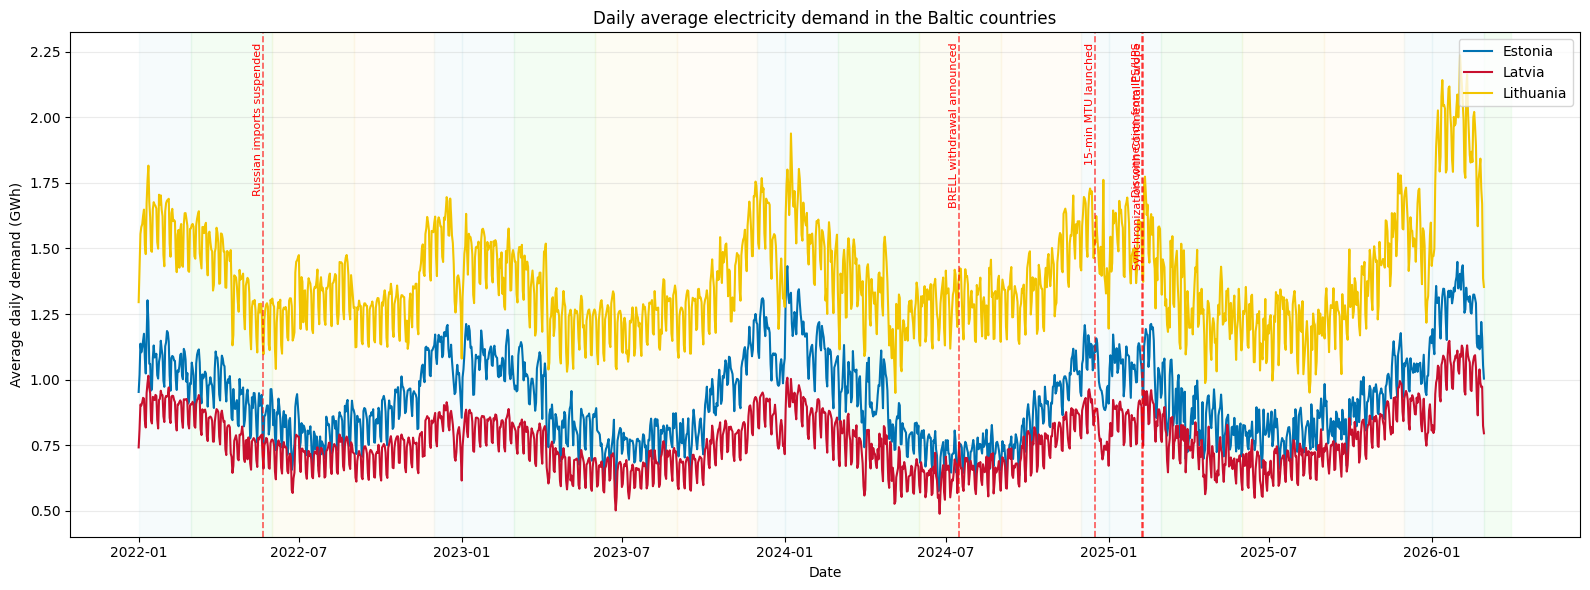

In [662]:
wind_cols = [
    "PROEEWINDON_ENTSOE",
    "PROLVWINDON_ENTSOE",
    "PROLTWINDON_ENTSOE"
]

solar_cols = [
    "PROEESOL_ENTSOE",
    "PROLVSOL_ENTSOE",
    "PROLTSOL_ENTSOE"
]

daily_cols = demand_cols + wind_cols + solar_cols

daily_data = (
    model_df
    .set_index("datadatetime")[daily_cols]
    .resample("D")
    .mean()
    .reset_index()
)

market_events = {
    "2022-05-22": "Russian imports suspended",
    "2024-07-16": "BRELL withdrawal announced",
    "2024-12-16": "15-min MTU launched",
    "2025-02-08": "Disconnection from IPS/UPS",
    "2025-02-09": "Synchronization with Continental Europe"
}


fig, ax = plt.subplots(figsize=(16, 6))

add_seasonal_background(ax, daily_data)

for col in demand_cols:

    ax.plot(
        daily_data["datadatetime"],
        daily_data[col],
        label=country_names[col],
        color=country_colors[col],
        linewidth=1.5
    )


# Market events
for date, label in market_events.items():

    date = pd.to_datetime(date)

    ax.axvline(
        date,
        color="red",
        linestyle="--",
        alpha=0.65,
        linewidth=1.2
    )

    ax.text(
        date,
        0.98,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        verticalalignment="top",
        horizontalalignment="right",
        fontsize=8,
        color="red"
    )


ax.set_xlabel("Date")
ax.set_ylabel("Average daily demand (GWh)")
ax.set_title("Daily average electricity demand in the Baltic countries")

ax.legend(
    loc="upper right",
    frameon=True
)

ax.grid(
    alpha=0.25,
    axis="y"
)

plt.tight_layout()
plt.show()

The first plot shows average daily electricity demand. Strong seasonality is visible, with lower demand in summer and higher demand in winter. Regular drops, likely related to weekends, can also be observed. Overall, the seasonal pattern is consistent, with no clear long-term trend but some noise.

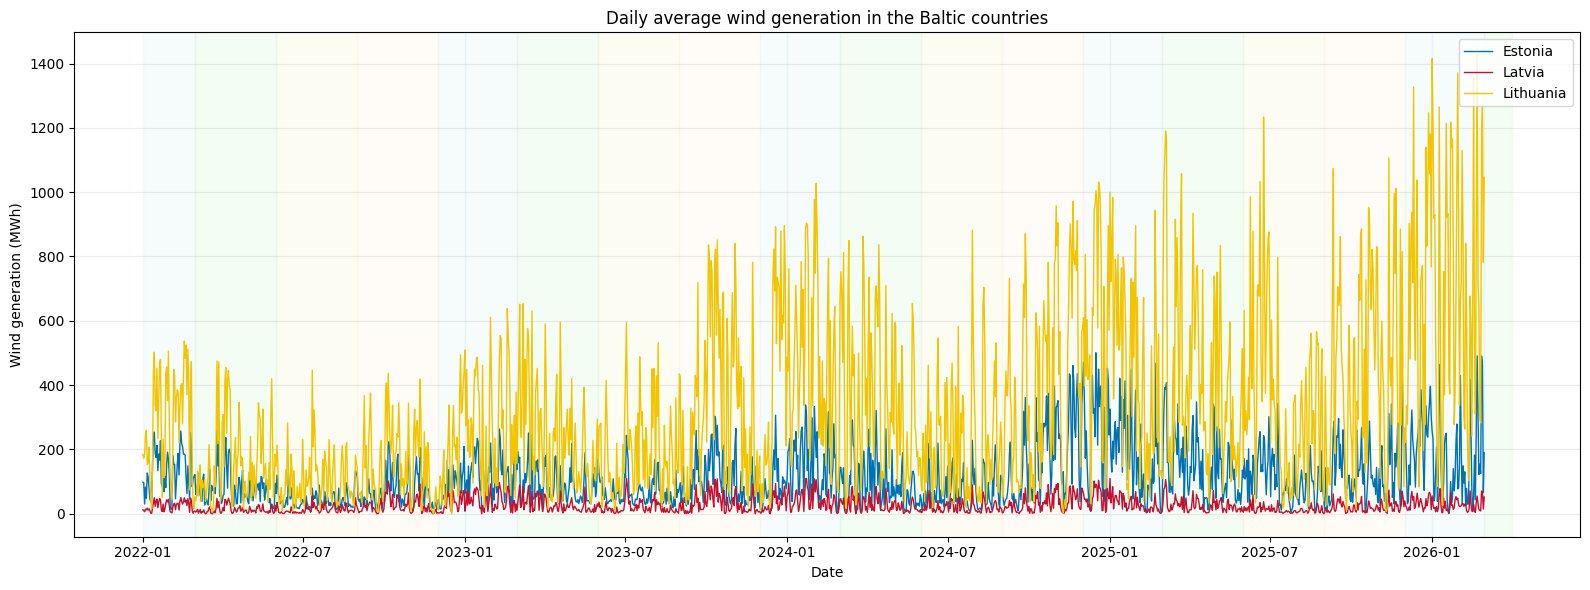

In [663]:
fig, ax = plt.subplots(figsize=(16, 6))

add_seasonal_background(ax, daily_data)

for col in wind_cols:

    country = "CNP" + col[3:5]

    ax.plot(
        daily_data["datadatetime"],
        daily_data[col],
        label=country_names[country],
        color=country_colors[country],
        linewidth=1
    )

ax.set_xlabel("Date")
ax.set_ylabel("Wind generation (MWh)")
ax.set_title("Daily average wind generation in the Baltic countries")

ax.legend(
    loc="upper right",
    frameon=True
)

ax.grid(
    alpha=0.25,
    axis="y"
)

plt.tight_layout()
plt.show()

A small seasonal pattern can be observed in wind generation, with somewhat higher generation during winter and spring. A significant increase in wind generation in Lithuania and Estonia is also visible over the last two years.

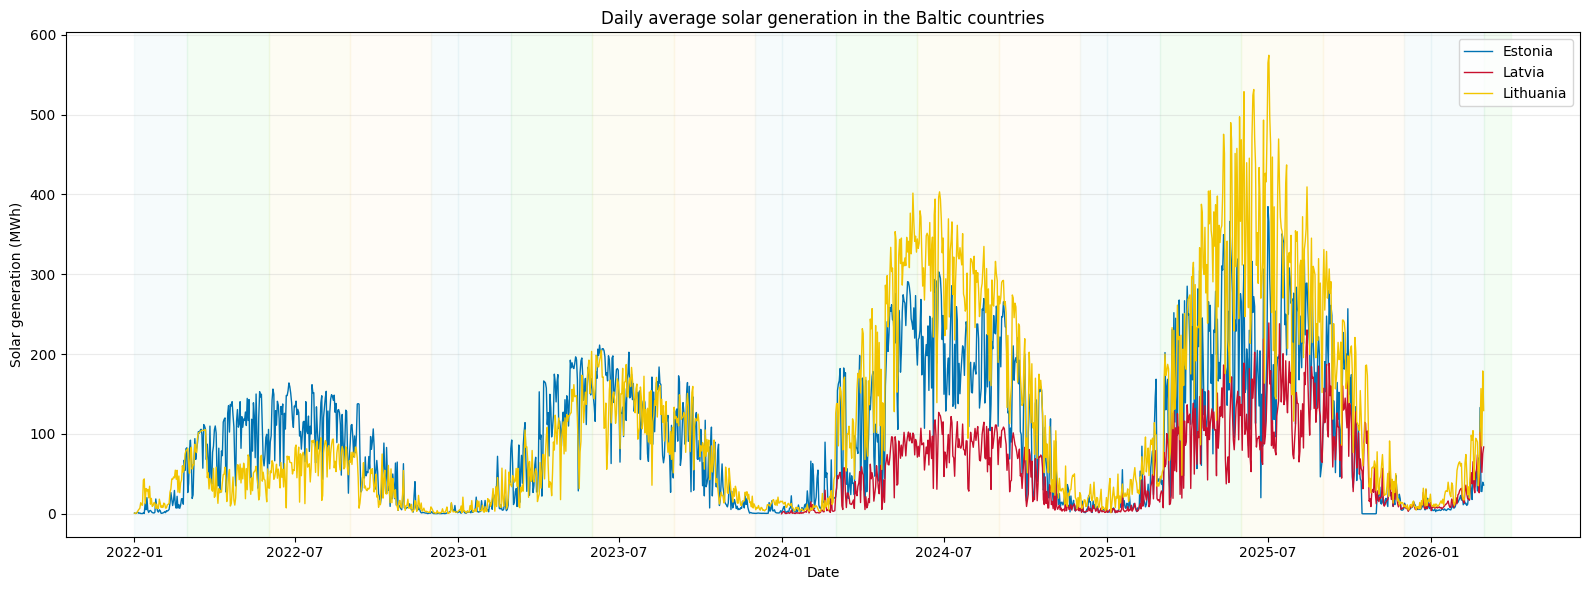

In [664]:
fig, ax = plt.subplots(figsize=(16, 6))

add_seasonal_background(ax, daily_data)

for col in solar_cols:

    country = "CNP" + col[3:5]

    ax.plot(
        daily_data["datadatetime"],
        daily_data[col],
        label=country_names[country],
        color=country_colors[country],
        linewidth=1
    )

ax.set_xlabel("Date")
ax.set_ylabel("Solar generation (MWh)")
ax.set_title("Daily average solar generation in the Baltic countries")

ax.legend(
    loc="upper right",
    frameon=True
)

ax.grid(
    alpha=0.25,
    axis="y"
)

plt.tight_layout()
plt.show()

Solar generation shows much stronger seasonality, with generation concentrated in the spring and summer months. The large number of missing values in Latvia is also visible, suggesting that Latvian solar generation data only became available around 2024.

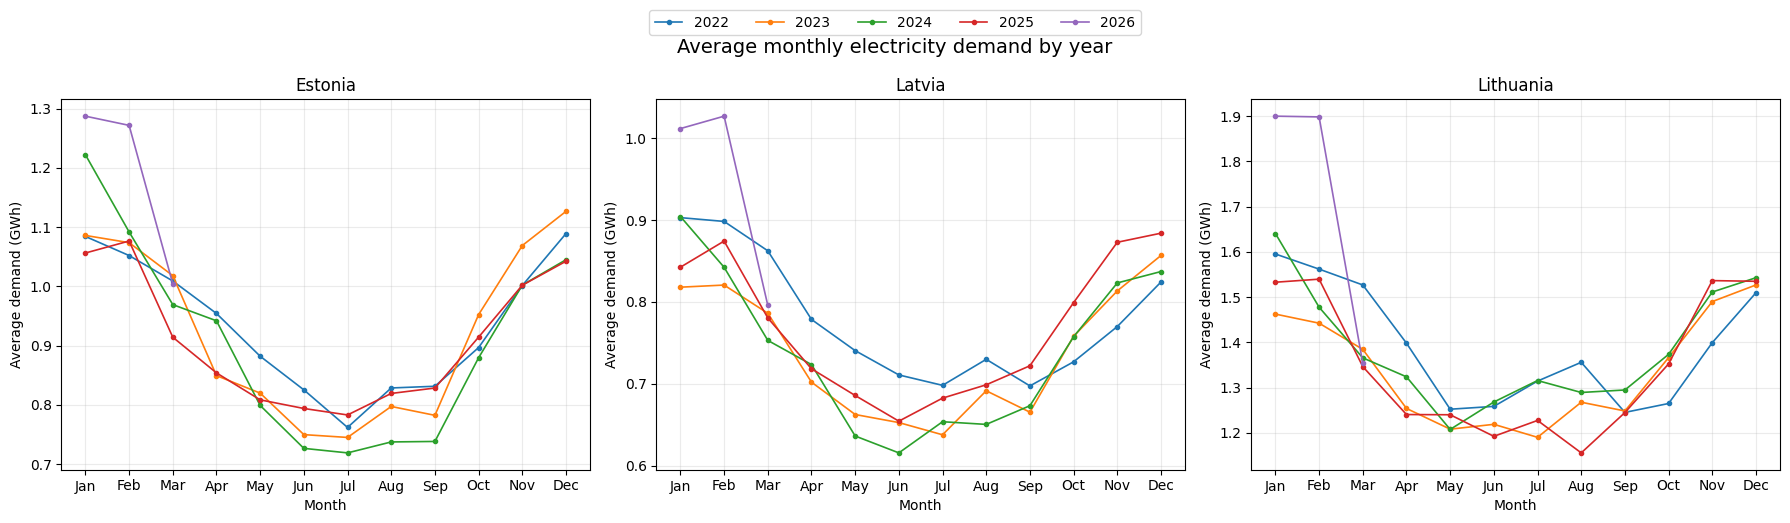

In [665]:
## Monthly average demand
monthly_demand = (
    model_df
    .set_index("datadatetime")[demand_cols]
    .resample("M")
    .mean()
    .reset_index()
)

# Extract year and month
monthly_demand["year"] = monthly_demand["datadatetime"].dt.year
monthly_demand["month"] = monthly_demand["datadatetime"].dt.month

# One plot per country
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    sharex=True
)

for ax, col in zip(axes, demand_cols):

    for year, data in monthly_demand.groupby("year"):

        ax.plot(
            data["month"],
            data[col],
            marker="o",
            markersize=3,
            linewidth=1.2,
            label=str(year)
        )

    ax.set_title(country_names[col])
    ax.set_xlabel("Month")
    ax.set_ylabel("Average demand (GWh)")
    
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ])
    
    ax.grid(alpha=0.25)

# Put one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.05)
)

fig.suptitle(
    "Average monthly electricity demand by year",
    fontsize=14
)

plt.tight_layout()
plt.show()

I also checked whether electricity demand shows any consistent trend or pattern across years. Overall, there is no clear increase in demand, although some unusual spikes can be observed in January and February 2026.

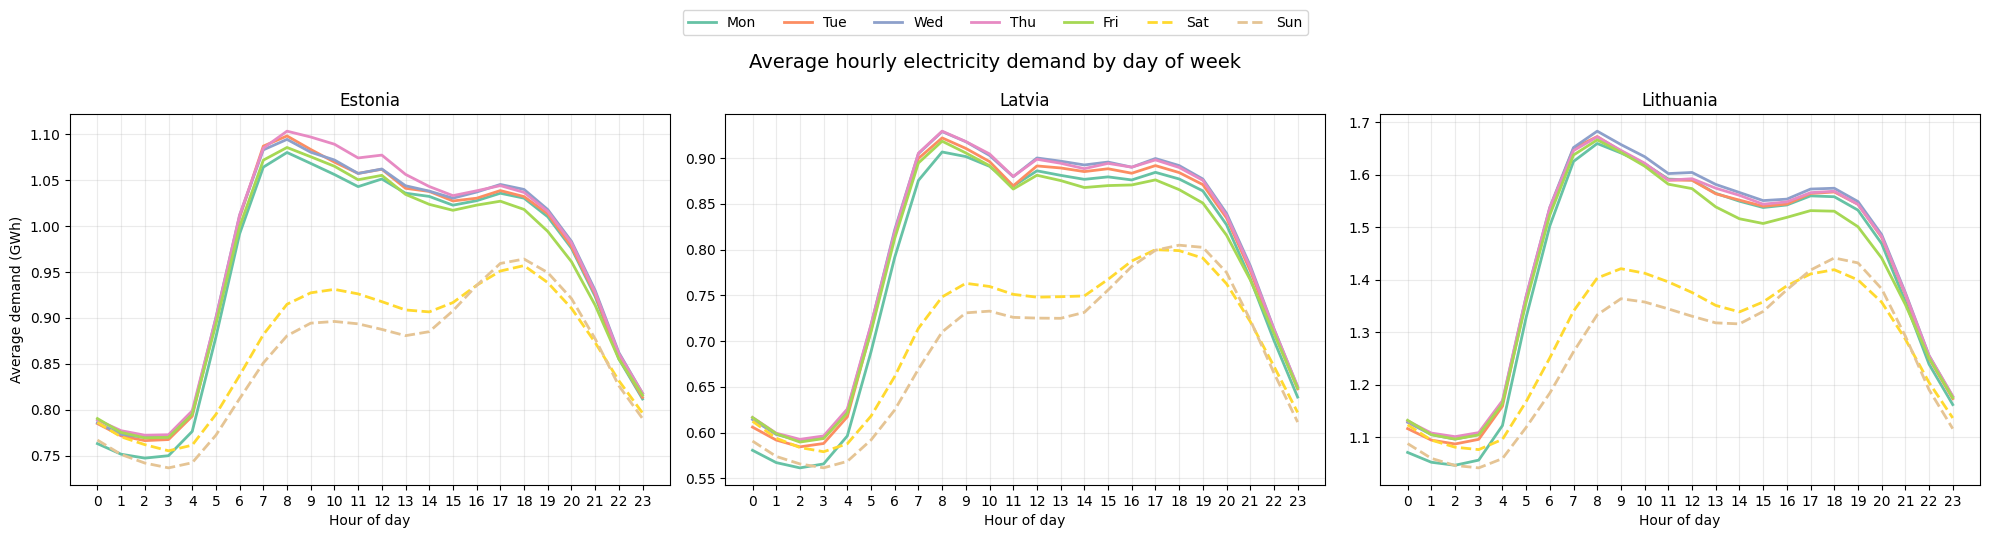

In [666]:
day_names = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
]

# Get 7 colors from a Matplotlib palette
colors = plt.cm.Set2.colors[:7]

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 5),
    sharey=False
)

for ax, demand_col in zip(axes, country_names.keys()):

    profile = (
        model_df
        .assign(
            hour=model_df["datadatetime"].dt.hour,
            weekday=model_df["datadatetime"].dt.dayofweek
        )
        .groupby(["weekday", "hour"])[demand_col]
        .mean()
        .unstack()
    )

    for weekday in range(7):

        # Weekdays: solid
        # Saturday/Sunday: dashed
        linestyle = "--" if weekday >= 5 else "-"

        ax.plot(
            profile.columns,
            profile.loc[weekday],
            label=day_names[weekday],
            color=colors[weekday],
            linewidth=2,
            linestyle=linestyle
        )

    ax.set_title(country_names[demand_col])
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(24))
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Average demand (GWh)")

# One common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=7
)

fig.suptitle(
    "Average hourly electricity demand by day of week",
    fontsize=14
)

plt.tight_layout()
plt.show()

Peak electricity demand occurs around 8 AM in all three countries. Weekday demand patterns are relatively similar, while weekends show noticeably different behaviour. This is an important finding for the modelling.

In [667]:
weather_wide_lv["year"] = weather_wide_lv["datadatetime"].dt.year

weather_vars = [
    "t2m",
    "tp",
    "solar_w_m",
    "wind_speed_10m",
    "wind_speed_100m"
]

annual_weather = (
    weather_wide_lv
    .groupby("year")[weather_vars]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

annual_weather.style.background_gradient(
    cmap="RdYlBu_r",
    axis=0
).format("{:.3f}")

Basic weather statistics were used to select the reference year. 2026 was excluded because the year is incomplete, while 2020 had an unusually warm winter. I selected 2023 because its minimum temperature of −15°C is relatively representative of the historical range. For this homework, I consider this analysis sufficient.

## Time series and relationship analysis

This section provides statistical reasoning for the modelling decisions. The main goal is to examine the relationships between electricity demand and potential model variables.

In [668]:
# Merging energy data with weather data
latvia_model = model_df.merge(
    weather_wide_lv,
    on="datadatetime",
    how="inner"
)

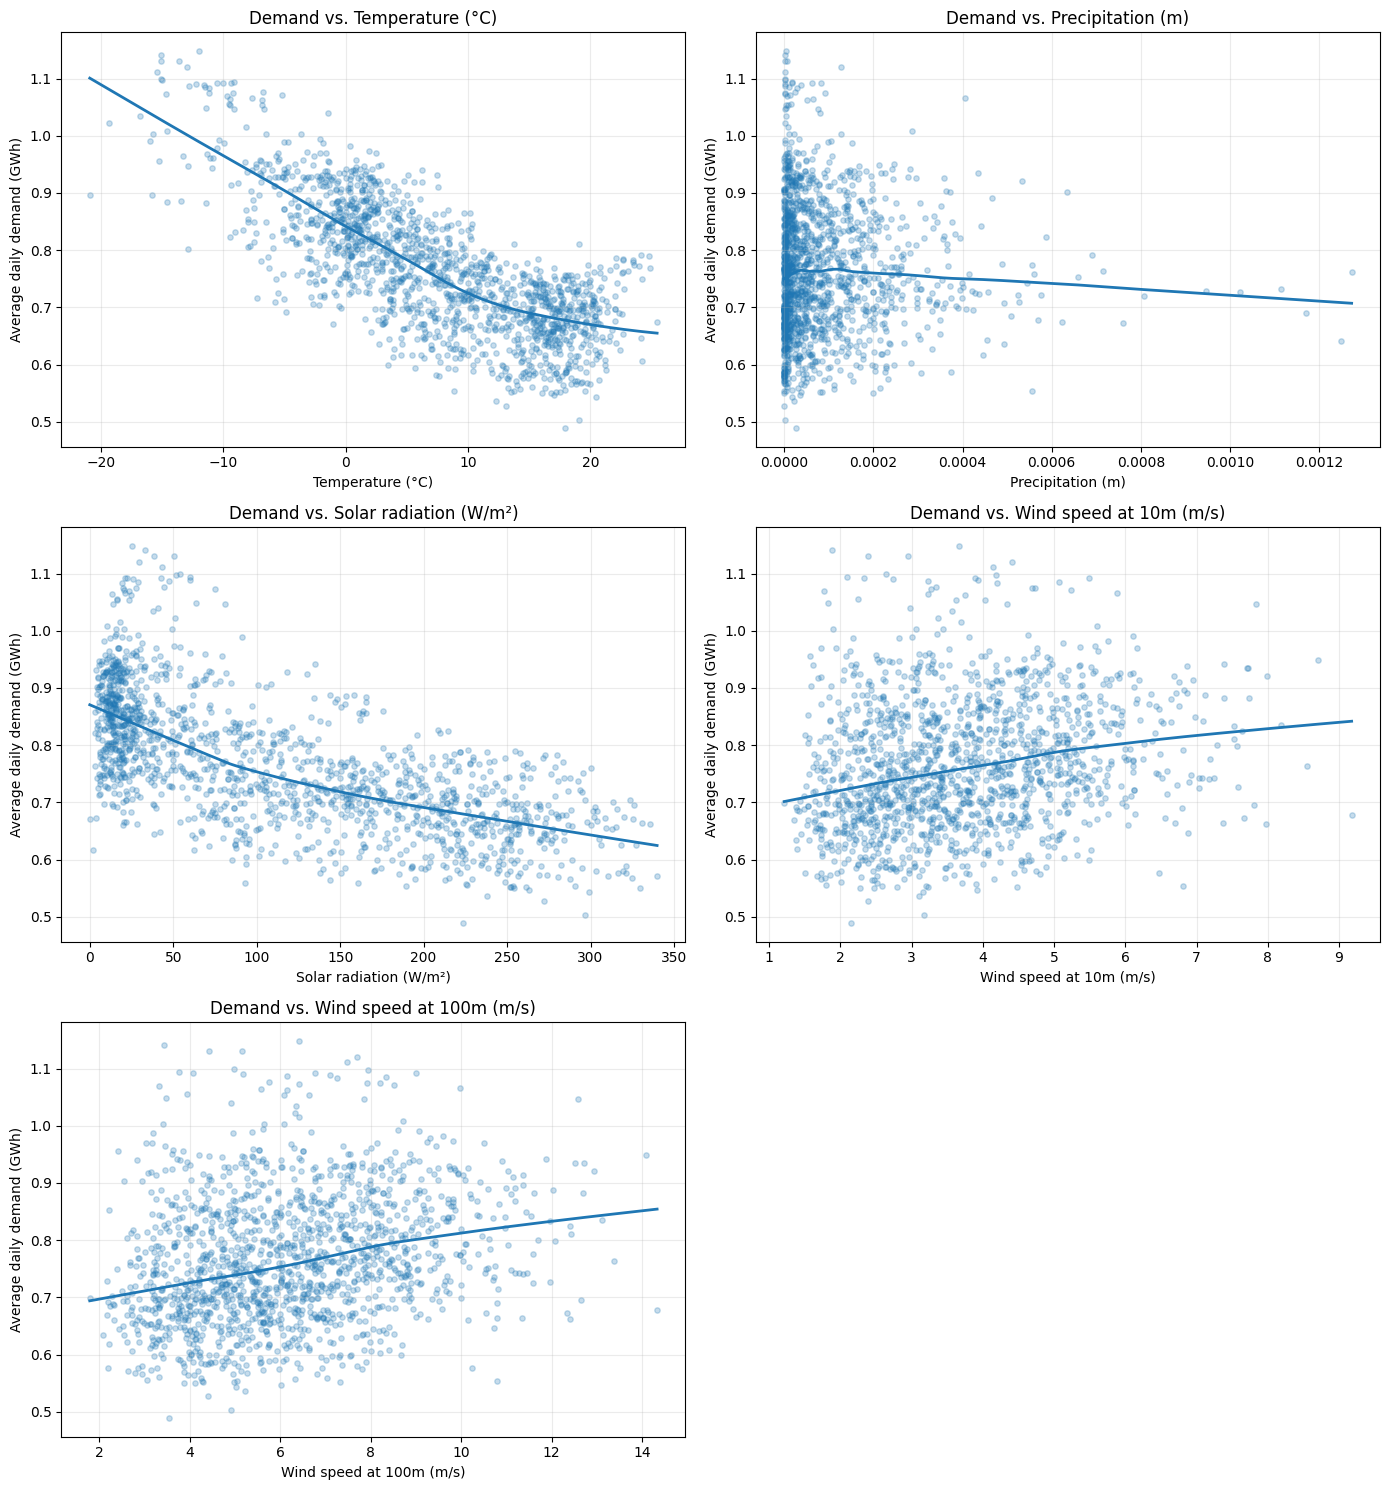

In [669]:
# Weahter relationship with the energy demand
variables = {
    "t2m": "Temperature (°C)",
    "tp": "Precipitation (m)",
    "solar_w_m": "Solar radiation (W/m²)",
    "wind_speed_10m": "Wind speed at 10m (m/s)",
    "wind_speed_100m": "Wind speed at 100m (m/s)"
}

# Daily aggregation
latvia_daily = (
    latvia_model
    .set_index("datadatetime")
    .resample("D")
    .agg({
        "CNPLV": "mean",
        **{var: "mean" for var in variables}
    })
    .dropna()
    .reset_index()
)

# 2-column figure
n_plots = len(variables)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for ax, (var, xlabel) in zip(axes, variables.items()):

    data = latvia_daily[[var, "CNPLV"]].dropna()

    sns.regplot(
        data=data,
        x=var,
        y="CNPLV",
        lowess=True,
        scatter_kws={
            "alpha": 0.25,
            "s": 15
        },
        line_kws={
            "linewidth": 2
        },
        ax=ax
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average daily demand (GWh)")
    ax.set_title(f"Demand vs. {xlabel}")
    ax.grid(alpha=0.25)

# Remove empty subplot if number of variables is odd
for ax in axes[n_plots:]:
    ax.remove()

plt.tight_layout()
plt.show()

The relationship between temperature and electricity demand appears to be nonlinear, with a U-shaped pattern: demand tends to increase at both low and high temperatures. This suggests that a simple linear regression may not capture the relationship well and provides grounds for exploring tree-based models.

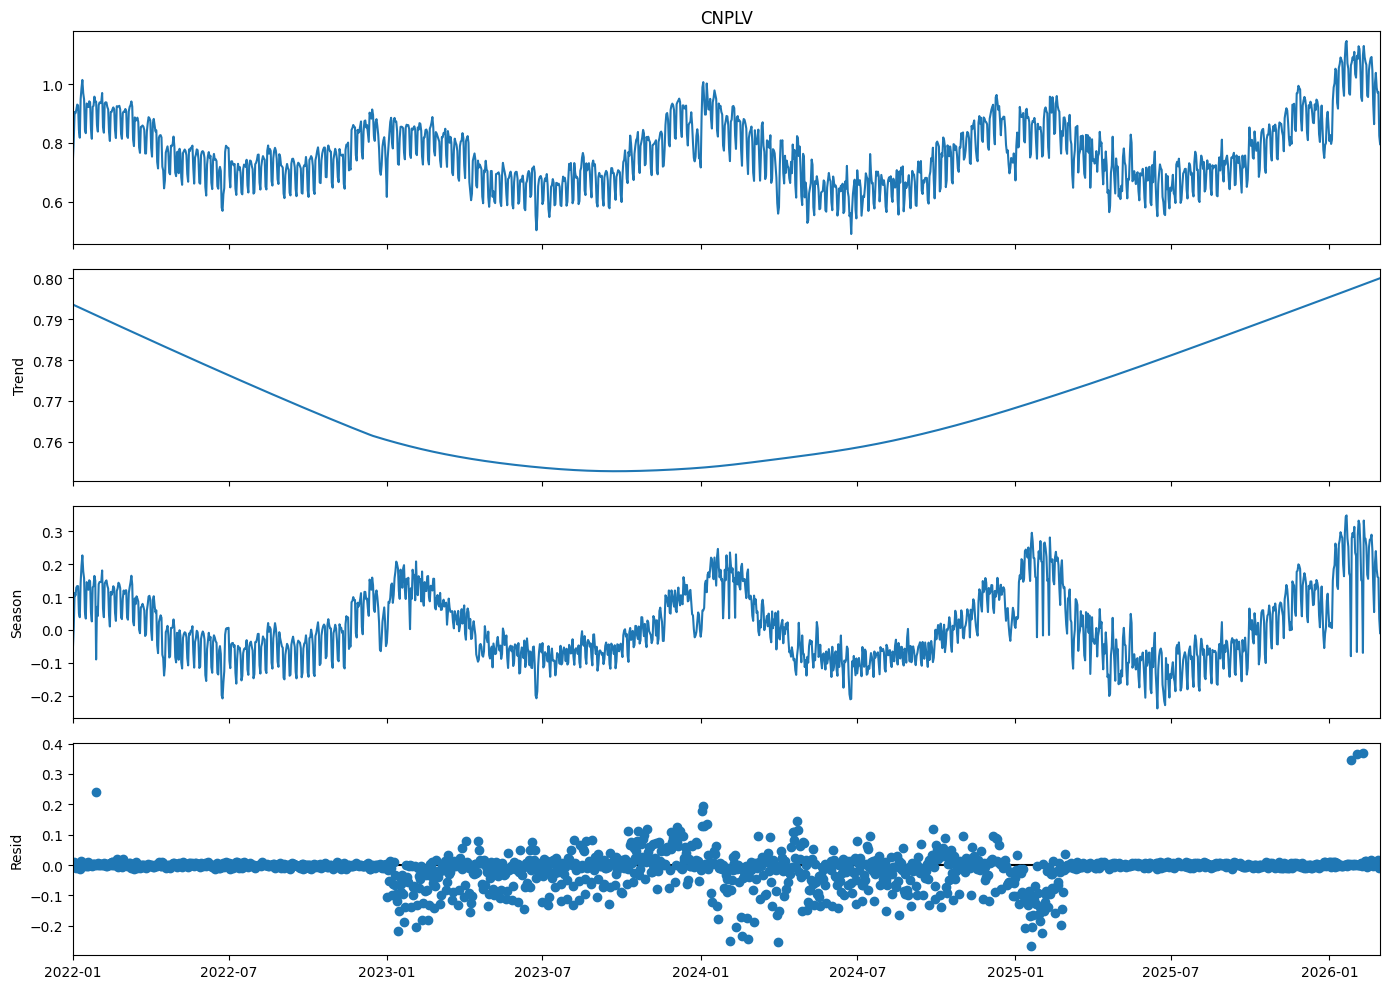

In [670]:
latvia = (
    model_df
    .set_index("datadatetime")["CNPLV"]
    .resample("D")
    .mean()
    .dropna()
)

stl = STL(
    latvia,
    period=365,
    robust=True
)

result = stl.fit()

fig = result.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

The decomposition shows that the trend and yearly seasonality explain most demand variation in 2022 and 2025, but perform less well during 2023–2024. Previous analysis also suggests that weekly seasonality should be considered.

In [ ]:
result = MSTL(
    latvia,
    periods=(7, 365)
).fit()

fig = result.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

Adding weekly seasonality reduces the average residual and the number of large outliers. However, a systematic residual shift appears at the beginning of 2025, suggesting a structural change that is worth investigating and potentially incorporating into the model.

In [ ]:
latvia_hourly = (
    model_df
    .set_index("datadatetime")["CNPLV"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(14, 6))

plot_acf(
    latvia_hourly,
    lags=24 * 7,
    ax=ax,
    alpha=0.05
)

ax.set_title(
    "Autocorrelation of hourly electricity demand – Latvia"
)

ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

Lastly, autocorrelation shows dependencies between observations. As expected, strong autocorrelation is present, suggesting that lagged demand variables could be useful in the model.

## Feature engineering

From this section it is expected to creat additional variables for model. Current variables are not enought or is need of transformation to exclude wrong bias of data. 

Furthermore, the model currently uses actual weather data. While this is appropriate for model development, a real forecast would need to use weather forecasts rather than future actual weather. Ideally, I would therefore use historical weather forecast data to analyse the difference between predicted and actual weather. I would still use actual weather for model development, but use forecasted weather when generating future demand forecasts.

Additionally would be interesting to have data for

* **Public holidays:** Christmas, New Year and Easter can have different consumption patterns and help explain unusual demand.
* **Consumption by sector:** household, industrial and commercial demand could help identify which sectors drive changes in total electricity demand.

In [ ]:
# Model will be created on LV data
target = 'CNPLV'

In [ ]:
# Calendar effect variables
latvia_model["hour"] = latvia_model["datadatetime"].dt.hour
latvia_model["weekday"] = latvia_model["datadatetime"].dt.dayofweek
latvia_model["month"] = latvia_model["datadatetime"].dt.month

In [ ]:
# There are two ways how to take into account day effect
# Seperating working day from weekend day

latvia_model["is_weekend"] = (
    latvia_model["weekday"] >= 5
).astype(int)

# Creating dummy variable for each day. Will check which performs better
weekday_dummies = pd.get_dummies(
    latvia_model["weekday"],
    prefix="weekday",
    drop_first=True
).astype(int)

latvia_model = pd.concat(
    [latvia_model, weekday_dummies],
    axis=1
)

In [ ]:
# Since hour 24 and 0 is next to each other, but their differenc is the biggest
# To remove unnessaracy biase Hour variable is converted into sin() and cos() coordinates

latvia_model["hour_sin"] = np.sin(
    2 * np.pi * latvia_model["hour"] / 24
)

latvia_model["hour_cos"] = np.cos(
    2 * np.pi * latvia_model["hour"] / 24
)

In [ ]:
# Months have the same issue
latvia_model["month_sin"] = np.sin(
    2 * np.pi * latvia_model["month"] / 12
)

latvia_model["month_cos"] = np.cos(
    2 * np.pi * latvia_model["month"] / 12
)

In [ ]:
# Again, since linear regreasson is used for linear trends, but 
# Relationship between demand and temparture is not linear, then 
# Temperature is converted to two linear variables, for better modeling
# But the in baltic states warm weather is not so strong, thus, it is not excpected to have
# big impact on the model

latvia_model["heating_degree"] = np.maximum(
    18 - latvia_model["t2m"], 0
)

latvia_model["cooling_degree"] = np.maximum(
    latvia_model["t2m"] - 18, 0
)

### Future data set for model prediction

In [ ]:
future_dates = pd.date_range(
    start="2026-03-01 00:00:00",
    end="2030-12-31 23:00:00",
    freq="h"
)

future = pd.DataFrame({
    "datadatetime": future_dates
})

# These are needed to merge the weather data
future["month"] = future["datadatetime"].dt.month
future["day"] = future["datadatetime"].dt.day
future["hour"] = future["datadatetime"].dt.hour

# 2023 year was selected as base year 
weather_2023 = (
    weather_wide_lv[
        weather_wide_lv["datadatetime"].dt.year == 2023
    ]
    .copy()
)

weather_2023["month"] = weather_2023["datadatetime"].dt.month
weather_2023["day"] = weather_2023["datadatetime"].dt.day
weather_2023["hour"] = weather_2023["datadatetime"].dt.hour

In [ ]:
weather_template = weather_2023[
    [
        "month",
        "day",
        "hour",
        "t2m",
        "tp",
        "solar_w_m",
        "wind_speed_10m",
        "wind_speed_100m"
    ]
]

future = future.merge(
    weather_template,
    on=["month", "day", "hour"],
    how="left"
)

In [ ]:
# Since 2023 is not a leap year, but 2028, then
# I am replacing 2028.02.29 data with data from 2024.02.29

weather_vars = [
    "t2m",
    "tp",
    "solar_w_m",
    "wind_speed_10m",
    "wind_speed_100m"
]

feb29_mask = (
    (future["datadatetime"].dt.year == 2028) &
    (future["datadatetime"].dt.month == 2) &
    (future["datadatetime"].dt.day == 29)
)

weather_feb29_2024 = (
    weather_wide_lv[
        (weather_wide_lv["datadatetime"].dt.year == 2024) &
        (weather_wide_lv["datadatetime"].dt.month == 2) &
        (weather_wide_lv["datadatetime"].dt.day == 29)
    ][weather_vars]
    .reset_index(drop=True)
)

future.loc[feb29_mask, weather_vars] = (
    weather_feb29_2024.values
)

In [ ]:
# For future predictions, I need the same variables

future["hour"] = future["datadatetime"].dt.hour
future["month"] = future["datadatetime"].dt.month
future["weekday"] = future["datadatetime"].dt.dayofweek

weekday_dummies = pd.get_dummies(
    future["weekday"],
    prefix="weekday",
    drop_first=True
).astype(int)

future = pd.concat(
    [future, weekday_dummies],
    axis=1
)

future["is_weekend"] = (
    future["weekday"] >= 5
).astype(int)

future["hour_sin"] = np.sin(
    2 * np.pi * future["hour"] / 24
)

future["hour_cos"] = np.cos(
    2 * np.pi * future["hour"] / 24
)

future["month_sin"] = np.sin(
    2 * np.pi * future["month"] / 12
)

future["month_cos"] = np.cos(
    2 * np.pi * future["month"] / 12
)

future["heating_degree"] = np.maximum(
    18 - future["t2m"],
    0
)

future["cooling_degree"] = np.maximum(
    future["t2m"] - 18,
    0
)

Splitting data set into train and test data sets to see whenever model performs good on the data it has not seen. Since this is the time seari, then split is based on the date not randombly on data points.

In [ ]:
split_date = "2025-01-01"

train = latvia_model[
    latvia_model["datadatetime"] < split_date
]

test = latvia_model[
    latvia_model["datadatetime"] >= split_date
]

## Modeling

For now, I have decided to use linear regression as the main model and compare its performance with a tree-based ML model. Linear regression provides a simple and interpretable baseline, while the ML model can capture nonlinear relationships and interactions between weather variables and demand. As a potential future comparison, SARIMAX could also be considered because it can explicitly model the strong temporal and seasonal patterns in demand.


P.S. The growth coefficient is implemented only in **Linear Regression – Version 1**. The additional discussion of the growth assumption is provided at the end of this section.

### Linear reagreasson

Since linear regression assumes independent errors, and we have observed autocorrelation in the residuals, the standard errors, p-values and t-statistics should be interpreted with caution or adjusted using methods such as HAC standard errors. However, autocorrelation does not necessarily invalidate the estimated coefficients or the model's predictions.

In [ ]:
linear_model = LinearRegression()

#### Version 1

In [ ]:
features = [
    "heating_degree",
    "cooling_degree",
    "solar_w_m",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "is_weekend"
]

In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [ ]:
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = (
    np.abs((y_test - y_pred) / y_test)
).mean() * 100

print(f"MAE: {mae:.3f} GWh")
print(f"RMSE: {rmse:.3f} GWh")
print(f"MAPE: {mape:.2f} %")
print(f"R_square: {r2:.3f}")

Linear Regression Version 1 explains around 70% of the variation in demand ($R^2 = 0.708$), with relatively low prediction error. Overall, I would consider this a reasonable baseline model.

##### Forcast from 2026 March 2030 for version 1

In [ ]:
X_future = future[features]
future["forecast_demand"] = linear_model.predict(X_future)

In [ ]:
future_daily = (
    future
    .set_index("datadatetime")["forecast_demand"]
    .resample("D")
    .mean()
    .reset_index()
)

In [ ]:
plt.figure(figsize=(16, 6))

plt.plot(
    future_daily["datadatetime"],
    future_daily["forecast_demand"],
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Forecast demand (GWh)")
plt.title(
    "Latvia electricity demand forecast "
    "(2026–2030, 2023 weather reference year)"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Implementation of the growth coefficient

In [ ]:
# Assume 1% annual structural demand growth
growth_rate = 0.01

future_daily["year"] = future_daily["datadatetime"].dt.year

future_daily["forecast_demand_adjusted"] = (
    future_daily["forecast_demand"]
    * (1 + growth_rate) ** (future_daily["year"] - 2026)
)

In [ ]:
plt.figure(figsize=(16, 6))

# Original weather-driven forecast
plt.plot(
    future_daily["datadatetime"],
    future_daily["forecast_demand"],
    linewidth=1.2,
    label="Weather-driven forecast"
)

# Weather + structural growth
plt.plot(
    future_daily["datadatetime"],
    future_daily["forecast_demand_adjusted"],
    linewidth=1.5,
    label="Weather-driven + 1% annual growth"
)

plt.xlabel("Date")
plt.ylabel("Forecast demand (GWh)")

plt.title(
    "Latvia electricity demand forecast "
    "(2026–2030, 2023 weather reference year)"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### Version 2

In [ ]:
features = [
    "heating_degree",
    "cooling_degree",
    
    "solar_w_m",
    "wind_speed_10m",
    
    "hour_sin",
    "hour_cos",
    
    "month_sin",
    "month_cos",
    
    "weekday_1",
    "weekday_2",
    "weekday_3",
    "weekday_4",
    "weekday_5",
    "weekday_6"
]

In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [ ]:
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = (
    np.abs((y_test - y_pred) / y_test)
).mean() * 100

print(f"MAE:  {mae:.3f} GWh")
print(f"RMSE: {rmse:.3f} GWh")
print(f"MAPE: {mape:.2f} %")
print(f"R_square: {r2:.3f}")

Version 2 of the linear regression uses the same variables as Version 1, but they are constructed differently. The results are practically identical, with no meaningful difference in model performance.

##### Forcast from 2026 March 2030 for version 2

In [ ]:
X_future = future[features]
future["forecast_demand"] = linear_model.predict(X_future)

future_daily = (
    future
    .set_index("datadatetime")["forecast_demand"]
    .resample("D")
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 6))

plt.plot(
    future_daily["datadatetime"],
    future_daily["forecast_demand"],
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Forecast demand (GWh)")
plt.title(
    "Latvia electricity demand forecast "
    "(2026–2030, 2023 weather reference year)"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Three based method

Since tree-based methods can capture nonlinear relationships, there is no need for the same variable transformations used in the linear regression model. However, the same underlying variables are used to make the comparison between the models consistent.

In [ ]:
features_rf = [
    "t2m",
    "solar_w_m",
    "hour",
    "month",
    "is_weekend"
]

X_train_rf = train[features_rf]
y_train_rf = train[target]

X_test_rf = test[features_rf]
y_test_rf = test[target]

In [ ]:
# Random forest was selected. Hyperparameters were AI suggested
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_model.predict(X_test_rf)

In [ ]:
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test_rf, y_pred_rf)
)

r2_rf = r2_score(y_test_rf, y_pred_rf)

mape_rf = (
    np.abs((y_test_rf - y_pred_rf) / y_test_rf)
).mean() * 100

print(f"MAE:{mae_rf:.3f} GWh")
print(f"RMSE:{rmse_rf:.3f} GWh")
print(f"MAPE:{mape_rf:.2f} %")
print(f"R_square:{r2_rf:.3f}")

The Random Forest model, without extensive fine-tuning, improved the results. It explains more of the variation in demand, with $R^2$ increasing to 78%, while the prediction error is also slightly lower.

In [ ]:
importance = pd.DataFrame({
    "Feature": features_rf,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

importance

The most important variable is the hour of the day, followed by temperatur

##### Forcast from 2026 March 2030 for random forest

In [ ]:
X_future = future[features_rf]
future["forecast_demand"] = rf_model.predict(X_future)

future_daily = (
    future
    .set_index("datadatetime")["forecast_demand"]
    .resample("D")
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 6))

plt.plot(
    future_daily["datadatetime"],
    future_daily["forecast_demand"],
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Forecast demand (GWh)")
plt.title(
    "Latvia electricity demand forecast "
    "(2026–2030, 2023 weather reference year)"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
future

#### Adding variables that capture historical demand

In time-series analysis, historical demand is autocorrelated, so I felt that these values could be useful as model variables. The main problem is that the forecast is required until 2030, so future lagged demand values would not be available. They could still be used through recursive forecasting, but errors could accumulate over such a long forecasting horizon. However, for short-term forecasting, I do not see an issue with having a live model that generates a new prediction for the next hour using the most recent demand data.

In [ ]:
# lag 1 - demand 1 houer ago
latvia_model["demand_lag_1"] = latvia_model[target].shift(1)
# lag 24 - demand 24 houers ago
latvia_model["demand_lag_24"] = latvia_model[target].shift(24)
# lag 168 - demand week ago (168 houers ago)
latvia_model["demand_lag_168"] = latvia_model[target].shift(168)

# First values does not have values, thus those are dropped
latvia_model = latvia_model.dropna(
    subset=["demand_lag_1", "demand_lag_24", "demand_lag_168"]
)

In [ ]:
features = [
    "heating_degree",
    "cooling_degree",
    "solar_w_m",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
    "demand_lag_1",
    "demand_lag_24",
    "demand_lag_168"
]

In [ ]:
train = latvia_model[
    latvia_model["datadatetime"] < split_date
]

test = latvia_model[
    latvia_model["datadatetime"] >= split_date
]

In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [ ]:
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

mape = (
    np.abs((y_test - y_pred) / y_test)
).mean() * 100

print(f"MAE: {mae:.3f} GWh")
print(f"RMSE: {rmse:.3f} GWh")
print(f"MAPE: {mape:.2f} %")
print(f"R_square: {r2:.3f}")

Indeed, this model explains 96% of the variation in demand, and the prediction error is very small. The model probably misses rare cases where unusually low or high demand is caused by unexpected events.

When considering structural changes in electricity demand, such as EV adoption, heat-pump electrification, industrial or data-centre growth, and energy-efficiency improvements, I would approach the problem in several stages.

* First, model performance should be **continuously monitored** using metrics such as MAE and RMSE. Persistent under- or overprediction under similar weather and calendar conditions could indicate structural changes in electricity consumption, such as EV adoption, heat-pump usage, industrial activity or energy efficiency.

* Ideally, structural changes **should be modelled** explicitly using forecasts of EV adoption, heat-pump penetration, industrial production, data-centre capacity, economic growth, and energy efficiency. This would require additional data for exampl:

    * number of registered EVs, EV registrations over time, estimated annual mileage, charging patterns and electricity consumption per vehicle;
    * installed data-centre capacity (MW), electricity consumption and planned new capacity;
    * GDP, household income, employment and population, which could help capture changes in overall economic activity (this actual is available in Central Statistical Bureau of Latvia);
    * And many more.

Overall, I would base changes to the model on observed data and performance evidence rather than assumptions about how a particular structural factor will affect demand.

When it comes to trusting the model output, we live in a rapidly changing world. AI, for example, has already changed markets and industries in ways that would have been difficult to predict ten years ago. If conditions remained stable, confidence could mainly be based on historical model error. Otherwise, confidence also depends on how well we can anticipate future changes. Economic growth, new technologies, policy changes, and geopolitical events can affect electricity demand in ways that historical data may not capture, especially when relevant data is limited or unavailable.

# Market Overview

How do you see the Baltic electricity market in 2050? Who are the main producers and what technologies dominate? What happens to prices, price volatility, and the role of interconnectors? What are the biggest uncertainties?

We’re interested in how you approach thinking about the energy system and future market developments, more than in how much you already know. Write as much as you can based on what you know and how you’d approach filling in the gaps.

I will admit that I do not come from an energy-related background, so my knowledge is limited in certain areas. However, I am very interested in learning more, and I find these questions particularly interesting.

I would start with electricity prices and price volatility. In one of my previous roles at SEB as a Junior Risk Controller in counterparty risk, I became particularly interested in financial derivatives. Commodities such as crude oil, gold and silver can serve as underlying assets for derivative contracts, which can help market participants manage and hedge price risk.

From this perspective, I expect energy markets to become increasingly important as geopolitical risks and the strategic importance of energy infrastructure increase. Higher uncertainty can also increase price volatility, creating greater demand for risk-management instruments such as futures and other derivatives.

Looking further ahead, I see several major sources of uncertainty, particularly **AI and geopolitical conflicts**.

* **AI:** AI is already contributing to scientific discoveries and helping researchers address problems that have remained difficult for decades. I believe continued advances in AI could accelerate the development of new technologies, potentially affecting how energy is produced, distributed and consumed.

* **Geopolitical conflicts:** Recent events have demonstrated the strategic importance of energy infrastructure and interconnectors. Energy dependence can create vulnerabilities and may encourage countries to develop policies aimed at increasing energy security and reducing dependence on external sources. Renewable energy could play an important role in this process, as resources such as wind and solar are widely available across the globe.

I therefore expect electricity to play an increasingly important role in financial markets, particularly as electrification increases and electricity becomes more important to industry and the wider economy.

Regarding the Baltic electricity market in 2050, I find it difficult to predict which technologies or producers will dominate. I expect the market to become more diversified, with multiple producers and technologies rather than a small number of dominant players.

I also believe that the technologies considered part of the renewable-energy landscape could expand as technology develops. For example, space-based solar power is already being researched by organisations such as NASA and ESA. While it is currently expensive and technically challenging, it illustrates how technologies that seem unrealistic today could potentially become relevant to the energy market in the longer term.
